In [310]:
import mofr

In [311]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from datetime import datetime, time, timedelta
from SynthSpread.spreadviewer_class import SpreadSingle, SpreadViewerData, norm_coeff
#from Database.TPData import TPData, TPDataDa, TPDataAssembly

from Strategies.LeadLagRegression_strategy.backtest_class import BacktestLL
from Strategies.LeadLagRegression_strategy.strategy_class import StrategyLL, VolumeClass
from support_functions import calculate_MACD, calculate_lead_lag_triggers, calculate_regression_model_price
tol=(1e-1)/2

import seaborn as sns


In [312]:
import seaborn as sns
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
from xgboost import XGBClassifier, plot_tree
import xgboost as xgb
import shap
from sklearn.model_selection import train_test_split
from sklearn import tree
from sklearn.tree import export_text
from sklearn.metrics import accuracy_score
from sklearn.linear_model import LogisticRegression

In [313]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [314]:
import warnings
warnings.filterwarnings('ignore')

In [315]:
max_secs_between_trades=60
cluster_trade_num_threshold=5
min_price_movement=0.05

burnout_period=30
stop_profit=0.3
makeagg_ratio=0.6

take_profit=0.5
stop_loss=-0.4

br_fee = 0.0175
closing_mode='Martinovo_zatvaranie'

In [316]:
##########################
param_dict = {}
param_dict['t_end'] = time(17)
param_dict['take_profit'] = take_profit
param_dict['stop_loss'] = stop_loss
param_dict['ba_max']=0.3

param_dict['burnout_period']=burnout_period
param_dict['stop_profit']=stop_profit
param_dict['makeagg_ratio']=makeagg_ratio

param_dict['br_fee'] = br_fee
##########################


strategy_class = StrategyLL(
                            strategy='LL',
                            market='de',
                            instrument='m2',
                            is_overnight=False,
                            closing_mode=closing_mode)

strategy_class.param_dict=param_dict

# Data preparation

In [317]:
data_lead = pd.read_csv(r's:\Algo\Files\andrej\Data\int_data_lead_dem1_oot_may_june.csv',
                    parse_dates=['datetime']).reset_index()

data_lag = pd.read_csv(r's:\Algo\Files\andrej\Data\int_data_lag_deq1_oot_may_june.csv',
                    parse_dates=['datetime']).reset_index()

In [318]:
data_lead['datetime']=pd.to_datetime(data_lead['datetime'], format='mixed')
data_lag['datetime']=pd.to_datetime(data_lag['datetime'], format='mixed')

In [319]:
data_lag['time_diff']=data_lag['datetime'].diff().dt.total_seconds().fillna(0)

In [320]:
data_lead=data_lead[data_lead['datetime'].apply(lambda x: x.hour>8 and  x.hour<18)]
data_lag=data_lag[data_lag['datetime'].apply(lambda x: x.hour>8 and  x.hour<18)]

In [321]:
data_lag['date']=data_lag['datetime'].apply(lambda x: x.date())

In [322]:
data_lag=calculate_MACD(data_lag)
data_lag=calculate_lead_lag_triggers(data_lead, data_lag, max_secs_between_trades, cluster_trade_num_threshold, min_price_movement)
data_lag=calculate_regression_model_price(data_lead, data_lag, 10, 10, 5)

In [323]:
def calc_time_since_predicted_price(row):
    
        return (row['datetime']-row['lag_price_predicted_datetime']).total_seconds()
   

In [324]:
 data_lag['time_since_predicted_price']=data_lag[['datetime', 'lag_price_predicted_datetime']].apply(lambda row: calc_time_since_predicted_price(row), axis=1)

In [325]:
data_lag.head()

,index,datetime,trd_price,volume,bid_price,ask_price,mid_price,trd_side,time_diff,date,MACD,trigger_datetime,trigger_action,lag_price_predicted,lag_price_predicted_datetime,time_since_predicted_price
0,0,2024-05-01 09:05:49,NaN,NaN,70.0,NaN,70.0,1,0.0,2024-05-01,NaN,NaT,NaN,NaN,NaT,NaN
1,1,2024-05-01 09:05:50,NaN,NaN,70.0,NaN,70.0,1,1.0,2024-05-01,NaN,NaT,NaN,NaN,NaT,NaN
2,2,2024-05-01 09:05:51,NaN,NaN,70.0,NaN,70.0,1,1.0,2024-05-01,NaN,NaT,NaN,NaN,NaT,NaN
3,3,2024-05-01 09:05:52,NaN,NaN,70.0,NaN,70.0,1,1.0,2024-05-01,NaN,NaT,NaN,NaN,NaT,NaN
4,4,2024-05-01 09:05:53,NaN,NaN,70.0,NaN,70.0,1,1.0,2024-05-01,NaN,NaT,NaN,NaN,NaT,NaN


# Target Calculation

In [326]:
def calculate_close_slot_long(open_price, open_time, row):
    
        if row['ask_price']-row['bid_price']>param_dict['ba_max']:
            return (0,0)
    
        strategy_class = StrategyLL(
                            strategy='LL',
                            market='de',
                            instrument='m2',
                            is_overnight=False,
                            closing_mode=closing_mode)

        strategy_class.param_dict=param_dict
        
        strategy_class.timestamp_ = row['datetime']
        strategy_class.mid_p = row['mid_price']
        strategy_class.bid_p = row['bid_price']
        strategy_class.ask_p = row['ask_price']
        strategy_class.trd_p = row['trd_price']
        strategy_class.trd_s = row['trd_side']
        strategy_class.time_diff=row['time_diff']
        
        strategy_class.position_dict['open_price']=open_price
        strategy_class.position_dict['volume']=1
        strategy_class.position_dict['open_time']=open_time
        
        strategy_class._position=1
        
        return strategy_class.calculate_close_slot()
    
def calculate_close_slot_short(open_price, open_time, row):

        if row['ask_price']-row['bid_price']>param_dict['ba_max']:
            return (0,0)
        
        strategy_class = StrategyLL(
                            strategy='LL',
                            market='de',
                            instrument='m2',
                            is_overnight=False,
                            closing_mode=closing_mode)

        strategy_class.param_dict=param_dict
        
        strategy_class.timestamp_ = row['datetime']
        strategy_class.mid_p = row['mid_price']
        strategy_class.bid_p = row['bid_price']
        strategy_class.ask_p = row['ask_price']
        strategy_class.trd_p = row['trd_price']
        strategy_class.trd_s = row['trd_side']
        strategy_class.time_diff=row['time_diff']
        
        strategy_class.position_dict['open_price']=open_price
        strategy_class.position_dict['volume']=-1
        strategy_class.position_dict['open_time']=open_time
        
        strategy_class._position=-1
        
        return strategy_class.calculate_close_slot()

    
def calculate_profit_long(row, df):
    
    if row['ask_price']-row['bid_price']>param_dict['ba_max']:
        return None
    
    open_price=row['ask_price']
    open_time=row['datetime']
    
    filtered_df=df[(df['date']==row['date'])&(df['datetime']>row['datetime'])]
    
    for index, row in filtered_df.iterrows():
        price,vol = calculate_close_slot_long(open_price, open_time, row)
        
        if price!=0 and vol!=0:
            return price-open_price-2*param_dict['br_fee']
    
    return 0

def calculate_profit_short(row, df):
    
    if row['ask_price']-row['bid_price']>param_dict['ba_max']:
        return None
    
    open_price=row['bid_price']
    open_time=row['datetime']
    
    filtered_df=df[(df['date']==row['date'])&(df['datetime']>row['datetime'])]
    
    for index, row in filtered_df.iterrows():
        price,vol = calculate_close_slot_short(open_price, open_time, row)
        
        if price!=0 and vol!=0:
            return open_price-price-2*param_dict['br_fee']
    
    return 0

In [327]:
df_filtered=data_lag[data_lag['time_since_predicted_price']<data_lag['time_diff']]

In [328]:
for date in sorted(list(set(df_filtered.date))):
    print(date)
    a=data_lag[data_lag['date']==date]
    df_filtered.loc[df_filtered['date']==date, 'profit_long']=df_filtered.loc[df_filtered['date']==date][['datetime', 'date', 'bid_price', 'ask_price']].apply(lambda row: calculate_profit_long(row, a), axis=1)
    df_filtered.loc[df_filtered['date']==date, 'profit_short']=df_filtered.loc[df_filtered['date']==date][['datetime', 'date', 'bid_price', 'ask_price']].apply(lambda row: calculate_profit_short(row, a), axis=1)

2024-05-02
2024-05-03
2024-05-06
2024-05-07
2024-05-08
2024-05-09
2024-05-10
2024-05-13
2024-05-14
2024-05-15
2024-05-16
2024-05-17
2024-05-20
2024-05-21
2024-05-22
2024-05-23
2024-05-24
2024-05-27
2024-05-28
2024-05-29
2024-05-30
2024-05-31
2024-06-03
2024-06-04
2024-06-05
2024-06-06
2024-06-07
2024-06-10
2024-06-11
2024-06-12
2024-06-13
2024-06-14
2024-06-17
2024-06-18
2024-06-19
2024-06-20
2024-06-21
2024-06-24
2024-06-25
2024-06-26
2024-06-27
2024-06-28


In [329]:
df_filtered=df_filtered[df_filtered['datetime'].apply(lambda x: x.hour>8 and  x.hour<17)]
df_filtered=df_filtered[df_filtered['datetime'].apply(lambda x: x.day!=10 or x.month==3)]

In [330]:
df_filtered.to_csv(r's:\Algo\Files\andrej\Data\int_data_lag_deq1_oot_may_june_enriched.csv')

# Model Calculation

In [331]:
seed=2

In [332]:
from sklearn.linear_model import LinearRegression
import statsmodels.api as sm
from sklearn.metrics import r2_score

## Long model 

In [333]:
df_filtered['price_diff']=df_filtered['lag_price_predicted']-df_filtered['ask_price']

In [334]:
fil1=df_filtered['MACD'].isnull()==False
fil2=df_filtered['price_diff'].isnull()==False
fil3=df_filtered['trigger_action'].isnull()==False
fil4=df_filtered['profit_long'].isnull()==False

In [335]:
df_modelling=df_filtered[fil1&fil2&fil3&fil4]

### Regression

In [336]:
# Independent variable (lead_log_ret) and dependent variable (lag_log_ret)
X_train = df_modelling[['MACD', 'price_diff', 'trigger_action']]
y_train = df_modelling['profit_long'].fillna(0)

# Add a constant to the independent variable
X_train = sm.add_constant(X_train)

# Fit the model using statsmodels
model = sm.OLS(y_train, X_train).fit()

# Predict the lag_log_ret for the current day using the model
# X_test = sm.add_constant(df_trds_indexed.loc[df_trds_indexed['date']==current_day, 'lead_log_ret'].fillna(0))
# r_squared_test = r2_score(df_trds_indexed.loc[df_trds_indexed['date']==current_day, 'lag_log_ret'].fillna(0), model.predict(X_test).fillna(0))

# Optionally, print the summary for each model
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:            profit_long   R-squared:                       0.010
Model:                            OLS   Adj. R-squared:                  0.010
Method:                 Least Squares   F-statistic:                     70.99
Date:                Mon, 05 Aug 2024   Prob (F-statistic):           1.12e-45
Time:                        16:04:47   Log-Likelihood:                -9311.6
No. Observations:               21148   AIC:                         1.863e+04
Df Residuals:                   21144   BIC:                         1.866e+04
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                     coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------
const             -0.1293      0.003    -38.

### XGBoost

In [337]:
df_modelling['y']=(df_modelling['profit_long']>0).apply(int)
df_modelling['y'].value_counts()

y
0    13839
1     7309
Name: count, dtype: int64

In [338]:
feature_cols=['MACD', 'price_diff', 'trigger_action']

In [339]:
X_train, X_test, y_train, y_test = train_test_split(df_modelling[feature_cols], df_modelling['y'], test_size=0.25, random_state=seed)

xgb_model = XGBClassifier(max_depth=3, gamma=1, min_child_weight=5, n_estimators=10)
xgb_model.fit(X_train,
              y_train)
df_modelling['XGB_SCORE']=xgb_model.predict_proba(df_modelling[feature_cols])[:, 1]
X_train['XGB_SCORE']=xgb_model.predict_proba(X_train[feature_cols])[:, 1]
X_test['XGB_SCORE']=xgb_model.predict_proba(X_test[feature_cols])[:, 1]

preds_ = xgb_model.predict_proba(X_test[feature_cols])

In [340]:
print('The Lift on the df set is: '+ str(mofr.metrics.lift(y_train, X_train['XGB_SCORE'])))
print('The gini on the df set is: '+ str(mofr.metrics.gini(y_train, X_train['XGB_SCORE'])))
print('The accuracy on the df set is: '+ str(mofr.metrics.accuracy_score(y_train, X_train['XGB_SCORE'].apply(lambda x: int(x>0.5)))))
print('\n')
print('The Lift on the test set is: '+ str(mofr.metrics.lift(y_test, X_test['XGB_SCORE'])))
print('The gini on the test set is: '+ str(mofr.metrics.gini(y_test, X_test['XGB_SCORE'])))
print('The accuracy on the test set is: '+ str(mofr.metrics.accuracy_score(y_test, X_test['XGB_SCORE'].apply(lambda x: int(x>0.5)))))
print('\n')

The Lift on the df set is: 1.5140830834540615
The gini on the df set is: 0.2171176574713476
The accuracy on the df set is: 0.6565159825988273


The Lift on the test set is: 1.3895461477717297
The gini on the test set is: 0.1688297406405912
The accuracy on the test set is: 0.6599205598638169




In [341]:
result=[]
for feat in feature_cols:
    gini=mofr.metrics.gini(df_modelling['y'], df_modelling[feat])
    result.append((feat,gini))
    
pd.DataFrame(result)

,0,1
0,MACD,0.091174
1,price_diff,0.077898
2,trigger_action,0.046115


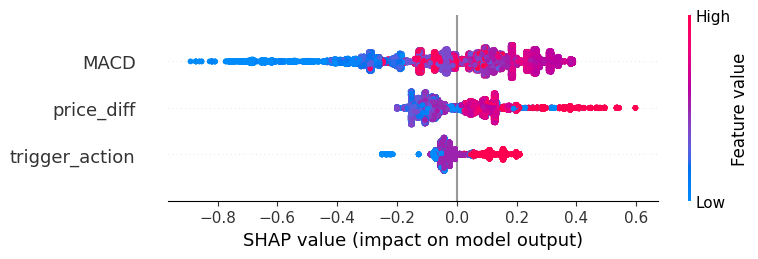

In [342]:
import shap
%matplotlib inline

explainer = shap.TreeExplainer(xgb_model)
shap_values = explainer.shap_values(df_modelling[feature_cols])
shap.summary_plot(shap_values, df_modelling[feature_cols])
plt.show()

#### **Precision curve**

In [343]:
preds_p = xgb_model.predict_proba(X_test[feature_cols])[:, 1]
#preds_p = model.predict(X_test).apply(lambda x: 1/(1+np.exp(-x)))

# threshold for more certainty in predicted values
thold_list = np.arange(0.2, 0.6, 0.001)
result = {'thold': [], 'precision': [], 'recall': [], 'count': []}
for thold in thold_list:
    preds = [1 if x > thold else 0 for x in preds_p]
    cm = confusion_matrix(y_test, preds)
    
    true_positives = cm[1, 1]  # Actual positive (1) and predicted positive (1)
    false_positives = cm[0, 1]  # Actual negative (0) but predicted positive (1)
    false_negatives = cm[1, 0]

    precision = true_positives / (true_positives + false_positives)
    recall = true_positives / (true_positives + false_negatives)
    result['thold'].append(thold)
    result['precision'].append(precision)
    result['recall'].append(recall)
    result['count'].append(true_positives + false_positives)
prec_recall_df = pd.DataFrame(result)

In [344]:
prec_recall_df[-50:]

,thold,precision,recall,count
350,0.550,NaN,0.0,0
351,0.551,NaN,0.0,0
352,0.552,NaN,0.0,0
353,0.553,NaN,0.0,0
354,0.554,NaN,0.0,0
355,0.555,NaN,0.0,0
356,0.556,NaN,0.0,0
357,0.557,NaN,0.0,0
358,0.558,NaN,0.0,0
359,0.559,NaN,0.0,0


### Interactions

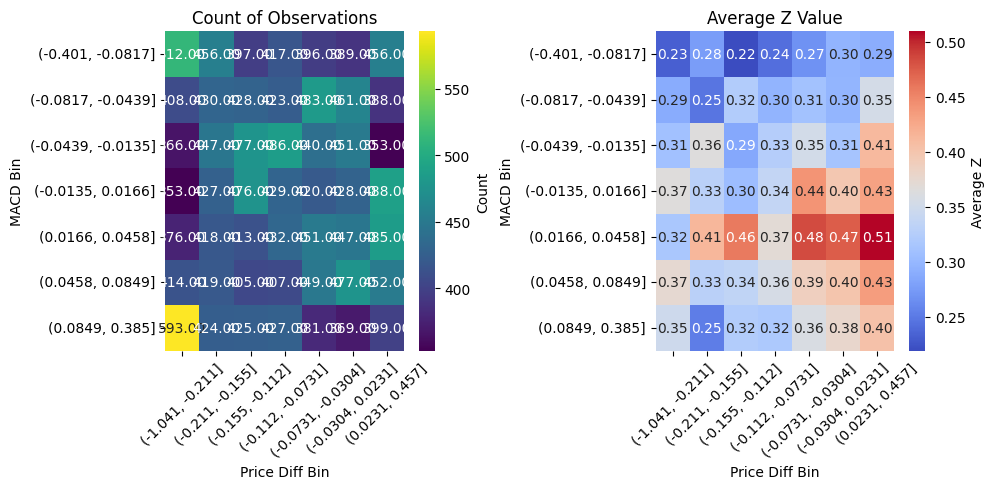

In [345]:
# Binning with interval labels
df_modelling.loc[:,'MACD_bin'] = pd.qcut(df_modelling['MACD'], 7, retbins=False, precision=3)
df_modelling.loc[:,'price_diff_bin'] = pd.qcut(df_modelling['price_diff'],7, retbins=False, precision=3)


# Create pivot tables
count_pivot = df_modelling.pivot_table(index='MACD_bin', columns='price_diff_bin', values='y', aggfunc='count')
mean_pivot = df_modelling.pivot_table(index='MACD_bin', columns='price_diff_bin', values='y', aggfunc='mean')

# Setup figure for heatmaps
plt.figure(figsize=(10,5))

# Heatmap for count of observations
plt.subplot(1, 2, 1)
sns.heatmap(count_pivot, annot=True, fmt=".2f", cmap='viridis', cbar_kws={'label': 'Count'})
plt.title('Count of Observations')
plt.xlabel('Price Diff Bin')
plt.ylabel('MACD Bin')
plt.xticks(np.arange(len(count_pivot.columns)) + 0.5, count_pivot.columns, rotation=45)
plt.yticks(np.arange(len(count_pivot.index)) + 0.5, count_pivot.index, rotation=0)

# Heatmap for average of Z
plt.subplot(1, 2, 2)
sns.heatmap(mean_pivot, annot=True, fmt=".2f", cmap='coolwarm', cbar_kws={'label': 'Average Z'})
plt.title('Average Z Value')
plt.xlabel('Price Diff Bin')
plt.ylabel('MACD Bin')
plt.xticks(np.arange(len(mean_pivot.columns)) + 0.5, mean_pivot.columns, rotation=45)
plt.yticks(np.arange(len(mean_pivot.index)) + 0.5, mean_pivot.index, rotation=0)

plt.tight_layout()
plt.show()

In [346]:
count_pivot

price_diff_bin,"(-1.041, -0.211]","(-0.211, -0.155]","(-0.155, -0.112]","(-0.112, -0.0731]","(-0.0731, -0.0304]","(-0.0304, 0.0231]","(0.0231, 0.457]"
MACD_bin,,,,,,,
"(-0.401, -0.0817]",512,456,397,417,396,389,456
"(-0.0817, -0.0439]",408,430,428,423,483,461,388
"(-0.0439, -0.0135]",366,447,477,486,440,451,353
"(-0.0135, 0.0166]",353,427,476,429,420,428,488
"(0.0166, 0.0458]",376,418,413,432,451,447,485
"(0.0458, 0.0849]",414,419,405,407,449,477,452
"(0.0849, 0.385]",593,424,425,427,381,369,399


In [347]:
mean_pivot

price_diff_bin,"(-1.041, -0.211]","(-0.211, -0.155]","(-0.155, -0.112]","(-0.112, -0.0731]","(-0.0731, -0.0304]","(-0.0304, 0.0231]","(0.0231, 0.457]"
MACD_bin,,,,,,,
"(-0.401, -0.0817]",0.232422,0.276316,0.219144,0.242206,0.267677,0.295630,0.289474
"(-0.0817, -0.0439]",0.289216,0.246512,0.322430,0.295508,0.310559,0.297180,0.353093
"(-0.0439, -0.0135]",0.308743,0.364653,0.285115,0.325103,0.352273,0.312639,0.410765
"(-0.0135, 0.0166]",0.365439,0.330211,0.304622,0.337995,0.440476,0.397196,0.430328
"(0.0166, 0.0458]",0.316489,0.413876,0.457627,0.370370,0.483370,0.474273,0.509278
"(0.0458, 0.0849]",0.374396,0.329356,0.335802,0.356265,0.387528,0.400419,0.433628
"(0.0849, 0.385]",0.347386,0.252358,0.322353,0.318501,0.359580,0.376694,0.403509


## Short model 

In [348]:
df_filtered['price_diff']=df_filtered['lag_price_predicted']-df_filtered['bid_price']

In [349]:
fil1=df_filtered['MACD'].isnull()==False
fil2=df_filtered['price_diff'].isnull()==False
fil3=df_filtered['trigger_action'].isnull()==False
fil4=df_filtered['profit_long'].isnull()==False

In [350]:
df_modelling=df_filtered[fil1&fil2&fil3&fil4]

In [351]:
# Independent variable (lead_log_ret) and dependent variable (lag_log_ret)
X_train = df_modelling[['MACD', 'price_diff', 'trigger_action']]
y_train = df_modelling['profit_short'].fillna(0)

# Add a constant to the independent variable
X_train = sm.add_constant(X_train)

# Fit the model using statsmodels
model = sm.OLS(y_train, X_train).fit()

# Predict the lag_log_ret for the current day using the model
# X_test = sm.add_constant(df_trds_indexed.loc[df_trds_indexed['date']==current_day, 'lead_log_ret'].fillna(0))
# r_squared_test = r2_score(df_trds_indexed.loc[df_trds_indexed['date']==current_day, 'lag_log_ret'].fillna(0), model.predict(X_test).fillna(0))

# Optionally, print the summary for each model
print(model.summary())


                            OLS Regression Results                            
Dep. Variable:           profit_short   R-squared:                       0.014
Model:                            OLS   Adj. R-squared:                  0.014
Method:                 Least Squares   F-statistic:                     100.7
Date:                Mon, 05 Aug 2024   Prob (F-statistic):           9.69e-65
Time:                        16:04:51   Log-Likelihood:                -9655.7
No. Observations:               21148   AIC:                         1.932e+04
Df Residuals:                   21144   BIC:                         1.935e+04
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                     coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------
const             -0.1247      0.003    -40.

### XGBoost

In [352]:
df_modelling['y']=(df_modelling['profit_short']>0).apply(int)
df_modelling['y'].value_counts()

y
0    13541
1     7607
Name: count, dtype: int64

In [353]:
feature_cols=['MACD', 'price_diff', 'trigger_action']

In [354]:
X_train, X_test, y_train, y_test = train_test_split(df_modelling[feature_cols], df_modelling['y'], test_size=0.25, random_state=seed)

xgb_model = XGBClassifier(max_depth=3, gamma=1, min_child_weight=5, n_estimators=10)
xgb_model.fit(X_train,
              y_train)
df_modelling['XGB_SCORE']=xgb_model.predict_proba(df_modelling[feature_cols])[:, 1]
X_train['XGB_SCORE']=xgb_model.predict_proba(X_train[feature_cols])[:, 1]
X_test['XGB_SCORE']=xgb_model.predict_proba(X_test[feature_cols])[:, 1]

preds_ = xgb_model.predict_proba(X_test[feature_cols])

In [355]:
print('The Lift on the df set is: '+ str(mofr.metrics.lift(y_train, X_train['XGB_SCORE'])))
print('The gini on the df set is: '+ str(mofr.metrics.gini(y_train, X_train['XGB_SCORE'])))
print('The accuracy on the df set is: '+ str(mofr.metrics.accuracy_score(y_train, X_train['XGB_SCORE'].apply(lambda x: int(x>0.5)))))
print('\n')
print('The Lift on the test set is: '+ str(mofr.metrics.lift(y_test, X_test['XGB_SCORE'])))
print('The gini on the test set is: '+ str(mofr.metrics.gini(y_test, X_test['XGB_SCORE'])))
print('The accuracy on the test set is: '+ str(mofr.metrics.accuracy_score(y_test, X_test['XGB_SCORE'].apply(lambda x: int(x>0.5)))))
print('\n')

The Lift on the df set is: 1.4877621231483322
The gini on the df set is: 0.21803464594653987
The accuracy on the df set is: 0.6429607212659983


The Lift on the test set is: 1.3816779579778065
The gini on the test set is: 0.1917023740117194
The accuracy on the test set is: 0.6510308303385663




In [356]:
result=[]
for feat in feature_cols:
    gini=mofr.metrics.gini(df_modelling['y'], df_modelling[feat])
    result.append((feat,gini))
    
pd.DataFrame(result)

,0,1
0,MACD,-0.079877
1,price_diff,-0.092637
2,trigger_action,-0.064838


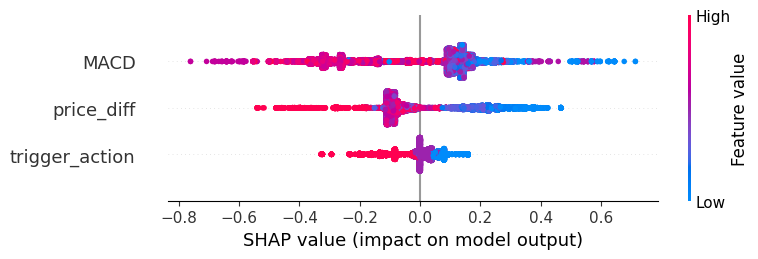

In [357]:
import shap
%matplotlib inline

explainer = shap.TreeExplainer(xgb_model)
shap_values = explainer.shap_values(df_modelling[feature_cols])
shap.summary_plot(shap_values, df_modelling[feature_cols])
plt.show()

#### **Precision curve**

In [358]:
preds_p = xgb_model.predict_proba(X_test[feature_cols])[:, 1]
#preds_p = model.predict(X_test).apply(lambda x: 1/(1+np.exp(-x)))

# threshold for more certainty in predicted values
thold_list = np.arange(0.2, 0.5, 0.001)
result = {'thold': [], 'precision': [], 'recall': [], 'count': []}
for thold in thold_list:
    preds = [1 if x > thold else 0 for x in preds_p]
    cm = confusion_matrix(y_test, preds)
    
    true_positives = cm[1, 1]  # Actual positive (1) and predicted positive (1)
    false_positives = cm[0, 1]  # Actual negative (0) but predicted positive (1)
    false_negatives = cm[1, 0]

    precision = true_positives / (true_positives + false_positives)
    recall = true_positives / (true_positives + false_negatives)
    result['thold'].append(thold)
    result['precision'].append(precision)
    result['recall'].append(recall)
    result['count'].append(true_positives + false_positives)
prec_recall_df = pd.DataFrame(result)

In [359]:
prec_recall_df[-50:]

,thold,precision,recall,count
250,0.450,0.478582,0.175041,677
251,0.451,0.477811,0.174500,676
252,0.452,0.476119,0.172339,670
253,0.453,0.476119,0.172339,670
254,0.454,0.483731,0.120475,461
255,0.455,0.483731,0.120475,461
256,0.456,0.487805,0.118855,451
257,0.457,0.495413,0.116694,436
258,0.458,0.496552,0.116694,435
259,0.459,0.496552,0.116694,435


### Interactions

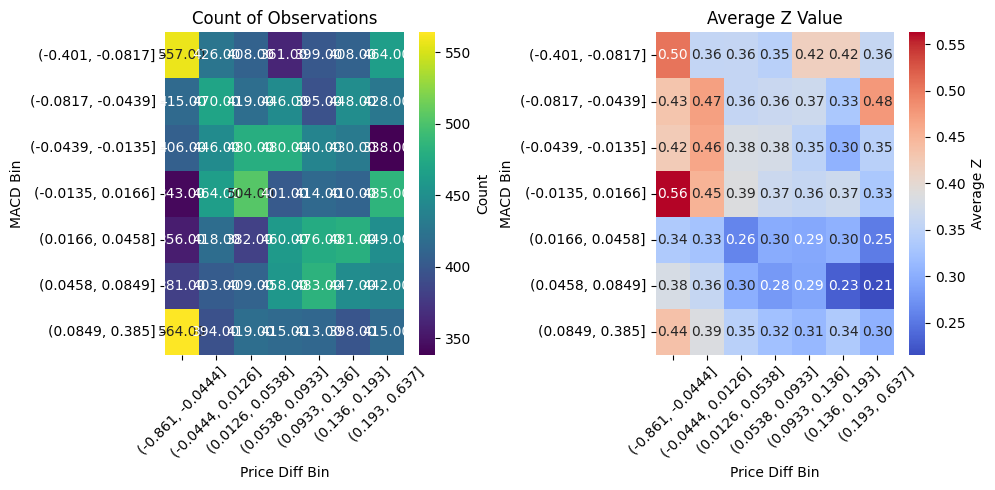

In [360]:
# Binning with interval labels
df_modelling.loc[:,'MACD_bin'] = pd.qcut(df_modelling['MACD'], 7, retbins=False, precision=3)
df_modelling.loc[:,'price_diff_bin'] = pd.qcut(df_modelling['price_diff'], 7, retbins=False, precision=3)


# Create pivot tables
count_pivot = df_modelling.pivot_table(index='MACD_bin', columns='price_diff_bin', values='y', aggfunc='count')
mean_pivot = df_modelling.pivot_table(index='MACD_bin', columns='price_diff_bin', values='y', aggfunc='mean')

# Setup figure for heatmaps
plt.figure(figsize=(10,5))

# Heatmap for count of observations
plt.subplot(1, 2, 1)
sns.heatmap(count_pivot, annot=True, fmt=".2f", cmap='viridis', cbar_kws={'label': 'Count'})
plt.title('Count of Observations')
plt.xlabel('Price Diff Bin')
plt.ylabel('MACD Bin')
plt.xticks(np.arange(len(count_pivot.columns)) + 0.5, count_pivot.columns, rotation=45)
plt.yticks(np.arange(len(count_pivot.index)) + 0.5, count_pivot.index, rotation=0)

# Heatmap for average of Z
plt.subplot(1, 2, 2)
sns.heatmap(mean_pivot, annot=True, fmt=".2f", cmap='coolwarm', cbar_kws={'label': 'Average Z'})
plt.title('Average Z Value')
plt.xlabel('Price Diff Bin')
plt.ylabel('MACD Bin')
plt.xticks(np.arange(len(mean_pivot.columns)) + 0.5, mean_pivot.columns, rotation=45)
plt.yticks(np.arange(len(mean_pivot.index)) + 0.5, mean_pivot.index, rotation=0)

plt.tight_layout()
plt.show()

In [361]:
count_pivot

price_diff_bin,"(-0.861, -0.0444]","(-0.0444, 0.0126]","(0.0126, 0.0538]","(0.0538, 0.0933]","(0.0933, 0.136]","(0.136, 0.193]","(0.193, 0.637]"
MACD_bin,,,,,,,
"(-0.401, -0.0817]",557,426,408,361,399,408,464
"(-0.0817, -0.0439]",415,470,419,446,395,448,428
"(-0.0439, -0.0135]",406,446,480,480,440,430,338
"(-0.0135, 0.0166]",343,464,504,401,414,410,485
"(0.0166, 0.0458]",356,418,382,460,476,481,449
"(0.0458, 0.0849]",381,403,409,458,483,447,442
"(0.0849, 0.385]",564,394,419,415,413,398,415


In [362]:
mean_pivot

price_diff_bin,"(-0.861, -0.0444]","(-0.0444, 0.0126]","(0.0126, 0.0538]","(0.0538, 0.0933]","(0.0933, 0.136]","(0.136, 0.193]","(0.193, 0.637]"
MACD_bin,,,,,,,
"(-0.401, -0.0817]",0.504488,0.356808,0.357843,0.346260,0.416040,0.416667,0.359914
"(-0.0817, -0.0439]",0.431325,0.470213,0.357995,0.363229,0.367089,0.332589,0.476636
"(-0.0439, -0.0135]",0.423645,0.464126,0.381250,0.377083,0.350000,0.304651,0.346154
"(-0.0135, 0.0166]",0.562682,0.452586,0.386905,0.366584,0.359903,0.368293,0.331959
"(0.0166, 0.0458]",0.337079,0.325359,0.261780,0.297826,0.294118,0.303534,0.253898
"(0.0458, 0.0849]",0.380577,0.359801,0.300733,0.279476,0.291925,0.230425,0.214932
"(0.0849, 0.385]",0.436170,0.385787,0.346062,0.322892,0.312349,0.336683,0.303614
